# Which Tier 2 Sudoku technique is worth learning first?

## tl;dr

- **W-Wing is the clear coverage-first choice in Sudoku Pilot's shipped catalog.** Added to Tier 1, it completes 26 of 100 Extreme puzzles. XY-Wing completes 10; the other five Tier 2 techniques complete none on their own.
- **The best second technique is 2-String Kite.** It unlocks no Extreme puzzles alone, yet adds 35 after W-Wing, taking coverage from 26 to 61.
- **Frequency is not necessity.** 2-String Kite appears in 83 Extreme traces, but disabling it from the full committed toolkit costs zero completions. Skyscraper also costs zero when provisional fallbacks remain available.
- **Scope matters.** The result is strong for the current 500-puzzle catalog. The 100 Extreme puzzles use two exact solution templates, so this is not evidence of a universal ranking across all Sudoku collections.

## Context & Methods

The decision is which of Sudoku Pilot's seven committed Tier 2 techniques a player should learn first when the objective is to finish more shipped puzzles. The unit of analysis is one canonical catalog puzzle. The population is all 500 shipped puzzles, with 100 puzzles at each difficulty.

### Key Assumptions

1. The player already knows every committed Tier 1 technique.
2. A puzzle counts as solved when Sudoku Pilot's logical solver completes it within 500 moves using only the allowed profile.
3. Incremental coverage compares Tier 1 with Tier 1 plus one Tier 2 technique.
4. Leave-one-out loss compares a full profile with the same profile after disabling one technique.
5. Shapley contribution averages each technique's marginal coverage across all 128 Tier 2 portfolios, removing dependence on one learning order.
6. The standard solver follows one deterministic move path. Two alternate move-selection policies test whether the headline rank changes. These checks do not prove necessity across every possible logical move order.

Regenerate the source artifact from the repository root with `npm run analyze:techniques`. The full sweep evaluates all 128 Tier 2 portfolios, two broader fallback profiles, alternate move policies, and catalog reconciliation checks.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'output' / 'technique-value-analysis-v0.1.json').exists():
    ROOT = ROOT.parent
SOURCE = ROOT / 'output' / 'technique-value-analysis-v0.1.json'
with SOURCE.open() as handle:
    analysis = json.load(handle)

assert analysis['dataQuality']['readyForAnalysis']
print(f"Loaded {analysis['population']['puzzles']} puzzles from {SOURCE.relative_to(ROOT)}")

Matplotlib is building the font cache; this may take a moment.


Loaded 500 puzzles from output/technique-value-analysis-v0.1.json


## Data

The source artifact is a fresh recomputation from the checked-in catalog and current solver. The reconciliation below checks grain, uniqueness, grid shape, solution agreement, stored step counts, stored technique sets, and every stored required-technique label.

In [2]:
quality = analysis['dataQuality']
quality_summary = pd.DataFrame([{
    'rows': quality['rowCount'],
    'unique_ids': quality['uniqueIds'],
    'unique_grids': quality['uniqueGrids'],
    'profile_failures': quality['levelProfileFailures'],
    'step_mismatches': quality['stepMismatches'],
    'technique_set_mismatches': quality['techniqueSetMismatches'],
    'solution_mismatches': quality['solutionMismatches'],
    'required_label_mismatches': quality['requiredTechniqueMismatches'],
}])
quality_summary

,rows,unique_ids,unique_grids,profile_failures,step_mismatches,technique_set_mismatches,solution_mismatches,required_label_mismatches
0,500,500,500,0,0,0,0,0


In [3]:
template_rows = [
    {'difficulty': level, **values}
    for level, values in quality['solutionTemplateConcentrationByLevel'].items()
]
pd.DataFrame(template_rows)

,difficulty,exactSolutionTemplates,largestTemplateCount,largestTemplateShare
0,easy,11,16,0.16
1,medium,8,18,0.18
2,hard,3,74,0.74
3,expert,13,10,0.10
4,extreme,2,50,0.50


## Results

W-Wing leads every coverage-oriented measure. Its 48.36-puzzle Shapley contribution accounts for more than half of the 84 Extreme puzzles solved by the committed Tier 2 portfolio. The broad leave-one-out column permits all five provisional detectors to act as fallbacks.

In [4]:
metrics = pd.DataFrame(analysis['techniqueMetrics'])
display_columns = [
    'technique',
    'soloIncrementalUnlocks',
    'shapleyMarginalPuzzles',
    'committedLeaveOneOutLoss',
    'allSupportedLeaveOneOutLoss',
    'storedTracePuzzleCount',
]
metrics[display_columns].sort_values('shapleyMarginalPuzzles', ascending=False).reset_index(drop=True)

,technique,soloIncrementalUnlocks,shapleyMarginalPuzzles,committedLeaveOneOutLoss,allSupportedLeaveOneOutLoss,storedTracePuzzleCount
0,W-Wing,26,48.360,50,50,50
1,X-Wing,0,9.560,13,3,58
2,XY-Wing,10,8.976,3,3,69
3,Skyscraper,0,7.210,6,0,82
4,2-String Kite,0,5.893,0,0,83
5,XYZ-Wing,0,2.193,3,3,22
6,Swordfish,0,1.810,1,1,31


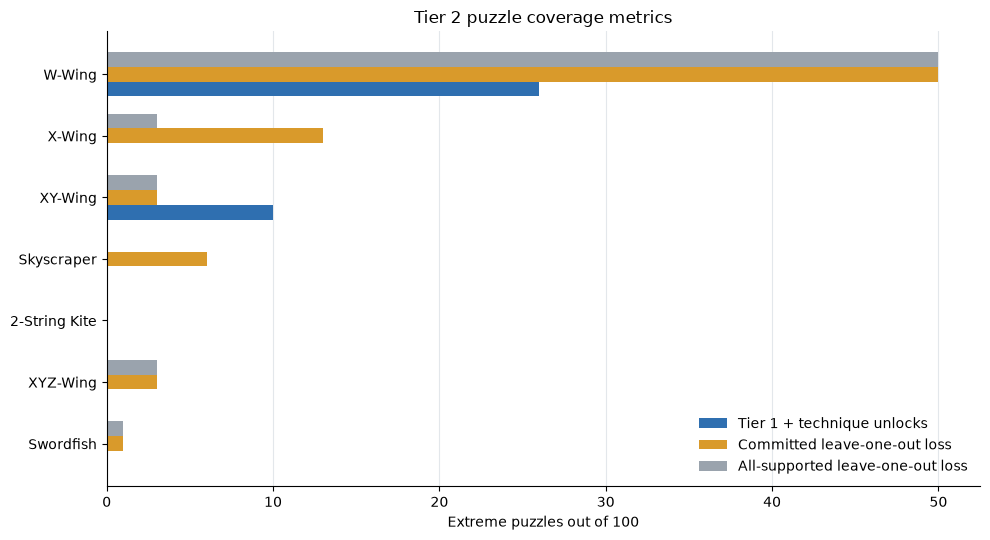

In [5]:
plot_data = metrics.sort_values('shapleyMarginalPuzzles', ascending=True)
y = np.arange(len(plot_data))
height = 0.24
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(y - height, plot_data['soloIncrementalUnlocks'], height, label='Tier 1 + technique unlocks', color='#2f6fb0')
ax.barh(y, plot_data['committedLeaveOneOutLoss'], height, label='Committed leave-one-out loss', color='#d99a2b')
ax.barh(y + height, plot_data['allSupportedLeaveOneOutLoss'], height, label='All-supported leave-one-out loss', color='#9aa3ad')
ax.set_yticks(y, plot_data['technique'])
ax.set_xlabel('Extreme puzzles out of 100')
ax.set_title('Tier 2 puzzle coverage metrics')
ax.grid(axis='x', color='#e3e7eb', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc='lower right')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

In [6]:
greedy = pd.DataFrame(analysis['greedyLearningOrder'])
greedy[['position', 'technique', 'incrementalExtremePuzzles', 'cumulativeSolvedByLevel']].assign(
    cumulative_extreme=lambda frame: frame['cumulativeSolvedByLevel'].map(lambda value: value['extreme'])
)[['position', 'technique', 'incrementalExtremePuzzles', 'cumulative_extreme']]

,position,technique,incrementalExtremePuzzles,cumulative_extreme
0,1,W-Wing,26,26
1,2,2-String Kite,35,61
2,3,X-Wing,13,74
3,4,Skyscraper,3,77
4,5,XY-Wing,3,80
5,6,XYZ-Wing,3,83
6,7,Swordfish,1,84


## Takeaways

1. **Learn W-Wing first for catalog coverage.** It is the only Tier 2 technique with unique solo unlocks and the recommendation is unchanged under all three move-selection policies.
2. **Learn 2-String Kite second if completion is the goal.** Its value appears through interaction with W-Wing: the pair completes 61 Extreme puzzles, 35 more than W-Wing alone.
3. **Treat Skyscraper and 2-String Kite as optional in a strict necessity sense.** Neither costs a completion when removed from the all-supported toolkit. This does not make them useless; both create common, accessible alternate paths.
4. **Defer Swordfish on coverage grounds.** It contributes 1.81 puzzles on average across learning orders and is strictly required for one shipped puzzle.
5. **Keep the recommendation scoped.** Sudoku Pilot balances its catalog for technique coverage and its Extreme set is concentrated in two exact solution templates. A second corpus with different construction rules is the most useful next validation.

A coverage score does not measure how hard a technique is to learn, how easy it is to spot, or how satisfying it is to use. Those inputs could support a separate benefit-per-study-hour ranking.